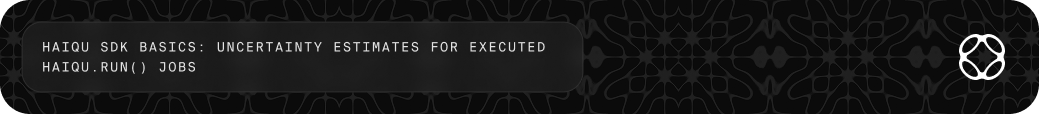

This notebook demonstrates how shot count affects the statistical uncertainty of expectation value estimates in `haiqu.run()`, and how enabling error mitigation changes that uncertainty.

- Haiqu reports per-observable uncertainty estimates in `job.info["uncertainty"]` for expectation value jobs.
- Uncertainty decreases as the number of shots increases, following a roughly `1/√shots` scaling.
- Enabling `use_mitigation=True` corrects the expectation value toward the ideal but may affect the reported uncertainty — this notebook lets you compare them directly.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `job.info["uncertainty"]`

- **What is it?** A per-observable estimate of the statistical uncertainty (standard error) in the measured expectation value, returned as a nested list matching the shape of the results.
- **How does shot count affect it?** Uncertainty scales as `~1/√shots` — doubling the shots reduces uncertainty by roughly `√2`.
- **How does mitigation affect it?** Error mitigation can shift the expectation value toward the ideal while adding or removing variance depending on the mitigation technique applied.
- **How do I read it?** `job.info["uncertainty"][circuit_idx][observable_idx]` gives the uncertainty for a specific circuit and observable combination.

**Note:** this notebook assumes some basic knowledge of Haiqu SDK. Make sure to read through [`haiqu_run.ipynb`](./haiqu_run.ipynb) notebook first.

## Initialize the example

Import the necessary libraries, initialize the Haiqu SDK, and build a 5-qubit Bell state circuit with a `ZZZZZ + XXXXX` observable. The ideal expectation value is 1.0.

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from haiqu.sdk import haiqu, set_haiqu_mpl_style

haiqu.login()
haiqu.init("Haiqu Uncertainty Estimate Tutorial")
set_haiqu_mpl_style()

circuit = QuantumCircuit(5)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 3)
circuit.cx(3, 4)

observable = SparsePauliOp.from_list([("ZZZZZ", 1), ("XXXXX", 1)])

haiqu.draw(circuit)

In [2]:
haiqu.list_simulators()

Vendor,Quantum System,Qubits,Status,Queue Length
IBM,aer_simulator,1024,online,0
IBM,fake_fez,156,online,0
IBM,fake_marrakesh,156,online,0
IBM,fake_torino,133,online,0
IBM,fake_kyoto,127,online,0
IBM,fake_washington,127,online,0
IBM,fake_kyiv,127,online,0
IBM,fake_sherbrooke,127,online,0
IBM,fake_brisbane,127,online,0
IBM,fake_quebec,127,online,0


In [3]:
device = haiqu.get_device("fake_fez")
options = {}

# Uncomment the following lines to run on the actual IBM Quantum device
# device = haiqu.get_device("ibm_fez")
# options = {
#     "ibm_quantum_token": "YOUR_IBM_QUANTUM_TOKEN",
#     "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",
# }

shot_counts = [50, 500, 5000, 50000, 500000]

In [4]:
# Compute ideal expectation value using statevector simulation
ideal_estimator = StatevectorEstimator()
ideal_result = ideal_estimator.run([(circuit, observable)]).result()
ideal_expval = float(ideal_result[0].data.evs.sum())
print(f"Ideal expectation value (ZZZZZ + XXXXX): {ideal_expval:.4f}")

Ideal expectation value (ZZZZZ + XXXXX): 1.0000


## Part 1: Uncertainty vs shot count (no mitigation)

We run the same circuit at five different shot counts on  a noisy simulator (`fake_fez`), then plot how the uncertainty evolves with the number of shots.

### Submit Jobs

In [5]:
# Submit noisy jobs (fake_fez — no mitigation)
noisy_job_ids = {}
for shots in shot_counts:
    job = haiqu.run(
        circuit,
        device=device,
        shots=shots,
        options=options,
        observables=observable,
    )
    noisy_job_ids[shots] = job.id
    print(f"Shots={shots:>7d}: {job.id}")

Shots=     50: jb-ae9babd5-388d-4902-a258-7c0f3d9b1a7b
Shots=    500: jb-fb9aad9a-2273-410e-b9d8-73fadc36bbc6
Shots=   5000: jb-1dd57dfe-a4d3-4a13-a15d-12d2c79d16f4
Shots=  50000: jb-f89469b2-ace1-4a4e-b89d-614b1eea672a
Shots= 500000: jb-7cc9cddf-5fe6-413d-95fe-8b6a5f3d44e9


### Retrieve Results

Run this cell to get results once the jobs are complete. For real QPU jobs, this may take minutes to hours. You can close the notebook and come back later—just use the saved job IDs to retrieve results.

**Note:** `job.result()` is a blocking call. If the job is not complete, it will wait until results are ready.

In [6]:
# Retrieve noisy results
noisy_expvals, noisy_uncertainties = {}, {}
for shots, job_id in noisy_job_ids.items():
    job = haiqu.get_job(job_id)
    result = job.result()
    noisy_expvals[shots] = result[0][0]
    noisy_uncertainties[shots] = job.info.get("uncertainty", [[0]])[0][0]
    print(f"Noisy shots={shots:>7d}: expval={noisy_expvals[shots]:.4f}  unc={noisy_uncertainties[shots]:.4f}")

Noisy shots=     50: expval=0.7200  unc=0.1600
Noisy shots=    500: expval=0.9200  unc=0.0479
Noisy shots=   5000: expval=0.9512  unc=0.0151
Noisy shots=  50000: expval=0.9684  unc=0.0048
Noisy shots= 500000: expval=0.9651  unc=0.0015


In [7]:
# Define a plotting utility function
def plot_uncertainty_estimate_results(shot_counts, series, ideal_expval, expectation_title, uncertainty_title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for expval_label, expvals, uncertainties, fmt in series:
        axes[0].errorbar(
            shot_counts,
            [expvals[s] for s in shot_counts],
            yerr=[uncertainties[s] for s in shot_counts],
            fmt=fmt,
            capsize=5,
            label=expval_label,
        )
    axes[0].axhline(ideal_expval, linestyle="--", label=f"Ideal value ({ideal_expval:.2f})")
    axes[0].set_xlabel("Number of Shots")
    axes[0].set_ylabel("Expectation Value")
    axes[0].set_xscale("log")
    axes[0].set_title(expectation_title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for uncertainty_label, _, uncertainties, fmt in series:
        axes[1].plot(
            shot_counts,
            [uncertainties[s] for s in shot_counts],
            fmt,
            label=uncertainty_label,
        )
    axes[1].set_xlabel("Number of Shots")
    axes[1].set_ylabel("Uncertainty")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title(uncertainty_title)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Plot: Expectation Value and Uncertainty vs Shots

In the plot below, we show how, with increasing shots, the uncertainty (error bars) decreases, and the expectation value converges toward some stable value. 

**Note**: Without error mitigation, the expectation value may be biased away from the ideal due to noise, indicating how `uncertainty` captures only the statistical error (or precision) but not the actual accuracy of the measurement.

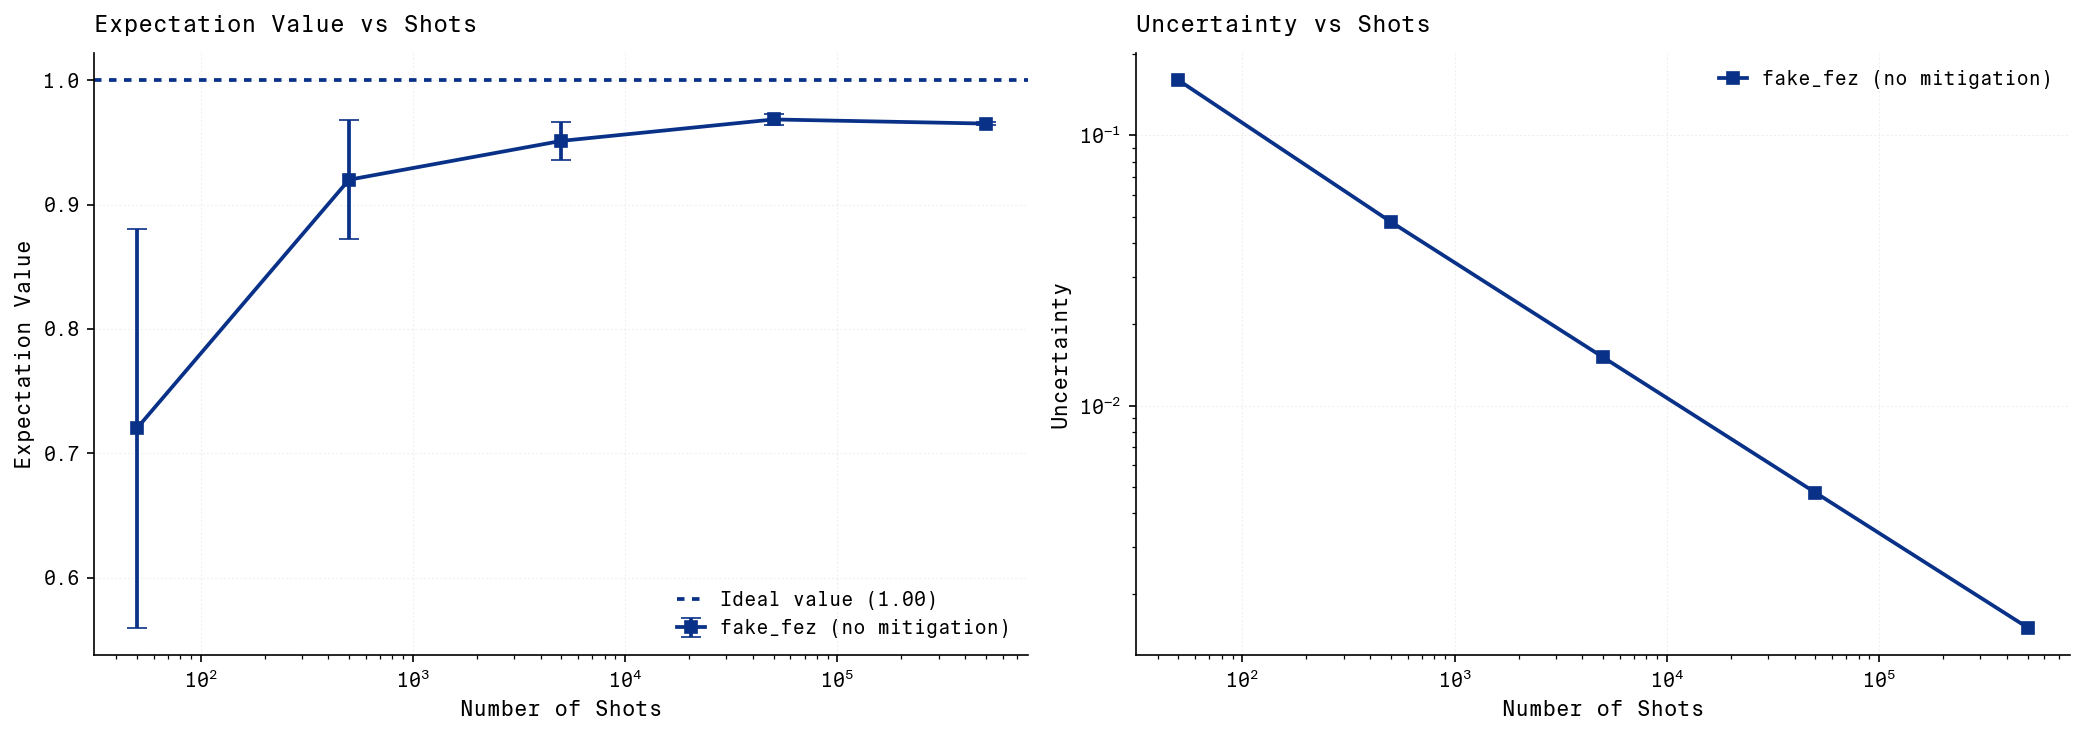

In [8]:
plot_uncertainty_estimate_results(
    shot_counts,
    [
        (
            f"{device.name} (no mitigation)",
            noisy_expvals,
            noisy_uncertainties,
            "s-",
        )
    ],
    ideal_expval,
    "Expectation Value vs Shots",
    "Uncertainty vs Shots",
)

## Part 2: Effect of mitigation on uncertainty

We repeat the same sweep on `fake_fez` with `use_mitigation=True` and compare both the expectation values and the uncertainties against the unmitigated run. This shows whether mitigation brings the result closer to the ideal value and how it affects the reported uncertainty.

### Submit Mitigated Jobs

In [9]:
# Submit mitigated jobs (fake_torino — with mitigation)
mitigated_job_ids = {}
for shots in shot_counts:
    job = haiqu.run(
        circuit,
        device=device,
        shots=shots,
        options=options,
        observables=observable,
        use_mitigation=True,
    )
    mitigated_job_ids[shots] = job.id
    print(f"Mitigated shots={shots:>7d}: {job.id}")

Mitigated shots=     50: jb-dcbf2726-1a77-402e-9bce-0200ebdf720d
Mitigated shots=    500: jb-96e4e166-19d8-4c01-b120-f58ea0f253d2
Mitigated shots=   5000: jb-2e9c919c-bb06-4505-a1ed-604496660a4c
Mitigated shots=  50000: jb-cb9d407b-d3c0-4703-9301-75e6082add3c
Mitigated shots= 500000: jb-a5ccc8d2-18d3-4e2b-b8ac-903653049940


### Retrieve Mitigated Results

Run this cell once the mitigated jobs are complete.

In [10]:
# Retrieve mitigated results
mitigated_expvals, mitigated_uncertainties = {}, {}
for shots, job_id in mitigated_job_ids.items():
    job = haiqu.get_job(job_id)
    result = job.result()
    mitigated_expvals[shots] = result[0][0]
    mitigated_uncertainties[shots] = job.info.get("uncertainty", [[0]])[0][0]
    print(f"Mitigated shots={shots:>7d}: expval={mitigated_expvals[shots]:.4f}  unc={mitigated_uncertainties[shots]:.4f}")

Mitigated shots=     50: expval=1.0000  unc=0.1539
Mitigated shots=    500: expval=0.9701  unc=0.0528
Mitigated shots=   5000: expval=0.9848  unc=0.0175
Mitigated shots=  50000: expval=0.9960  unc=0.0056
Mitigated shots= 500000: expval=1.0038  unc=0.0018


### Plot: Mitigation Comparison

After using error mitigation, we note how the accuracy of the expectation value improves (moving closer to the ideal) at a cost of a slight increase in uncertainty (see the plot on the right), demonstrating the trade-off between bias and variance when applying error mitigation techniques.

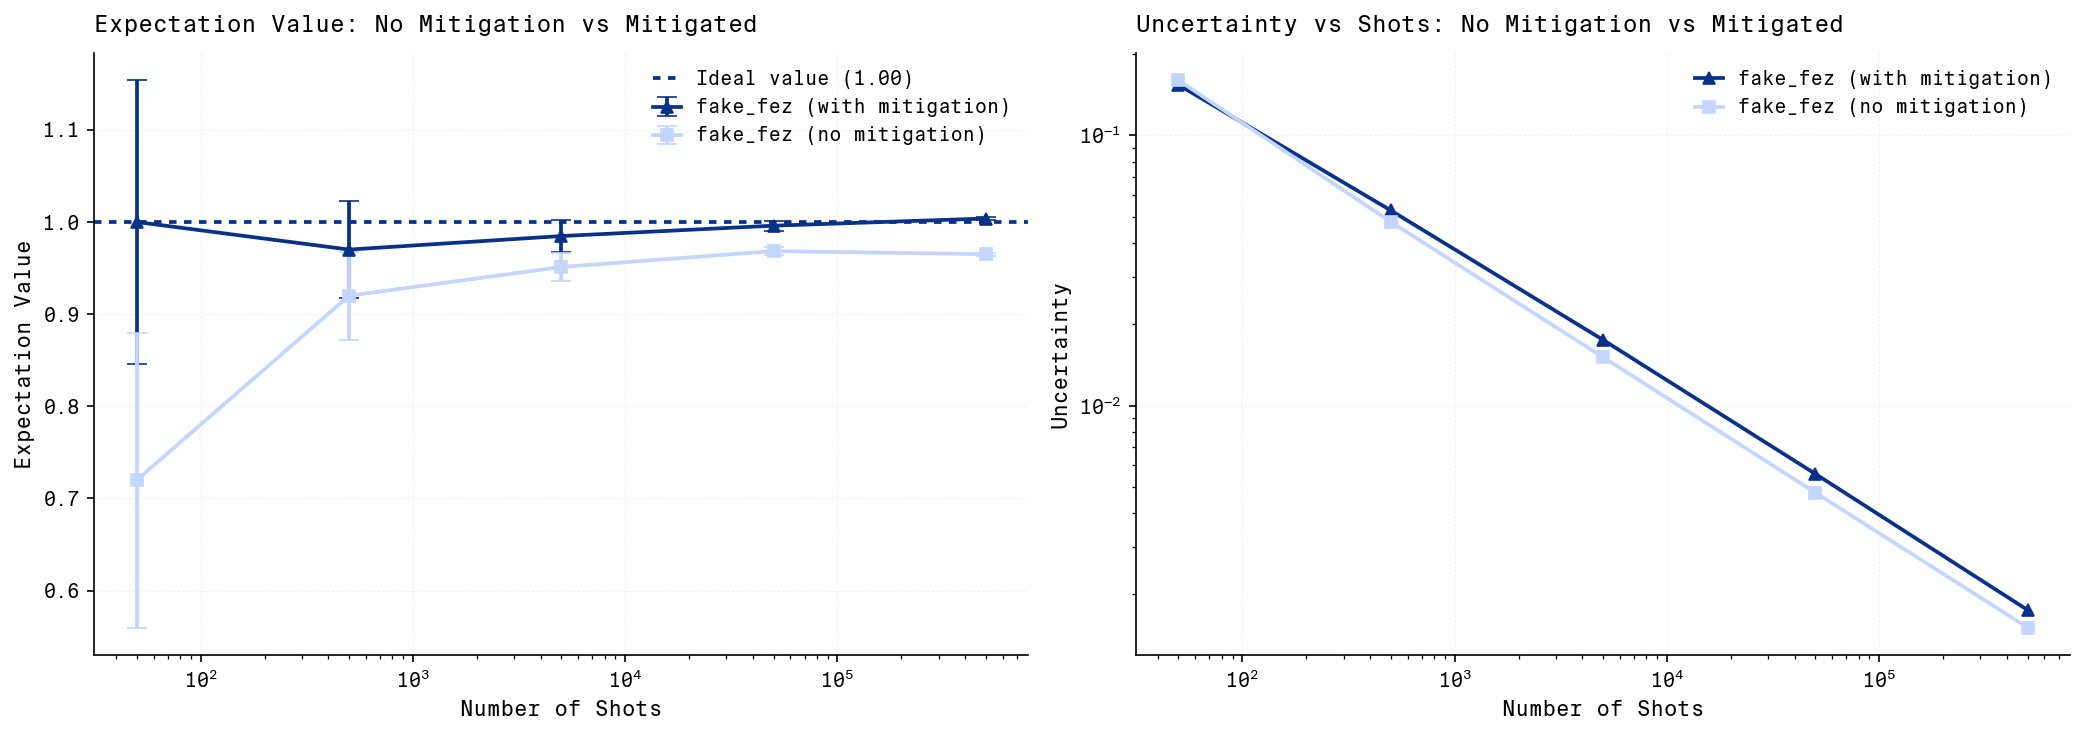

    Shots   No-mit expval  No-mit uncertainty   Mitigated expval  Mitigated uncertainty
       50          0.7200       0.1600             1.0000          0.1539
      500          0.9200       0.0479             0.9701          0.0528
     5000          0.9512       0.0151             0.9848          0.0175
    50000          0.9684       0.0048             0.9960          0.0056
   500000          0.9651       0.0015             1.0038          0.0018


In [11]:
plot_uncertainty_estimate_results(
    shot_counts,
    [
        (
            f"{device.name} (with mitigation)",
            mitigated_expvals,
            mitigated_uncertainties,
            "^-",
        ),
        (
            f"{device.name} (no mitigation)",
            noisy_expvals,
            noisy_uncertainties,
            "s-",
        ),
    ],
    ideal_expval,
    "Expectation Value: No Mitigation vs Mitigated",
    "Uncertainty vs Shots: No Mitigation vs Mitigated",
)
# Summary table
print(f"{'Shots':>9s}  {'No-mit expval':>14s}  {'No-mit uncertainty':>11s}  {'Mitigated expval':>17s}  {'Mitigated uncertainty':>14s}")
for s in shot_counts:
    print(f"{s:>9d}  {noisy_expvals[s]:>14.4f}  {noisy_uncertainties[s]:>11.4f}  {mitigated_expvals[s]:>17.4f}  {mitigated_uncertainties[s]:>14.4f}")

> **💡 Good to Know:** Uncertainty estimates are only available for observable estimation tasks (i.e., when `observables` is provided). For sampling tasks, use `job.quality` (Hellinger fidelity) to assess result quality instead. You can combine `use_mitigation=True` with `error_mitigation_options` to fine-tune which mitigation layers are applied — see the *Mitigation Options* notebook for details.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

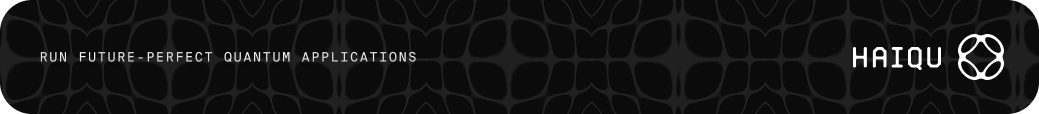